In [8]:
import omicverse as ov
import scvelo as scv
import pertpy as pt

In [9]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import os
import sys
import scipy
import matplotlib
from matplotlib import rcParams
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all" # to show output from all the lines in a cells
pd.set_option('display.max_column',None) # display all the columns in pandas
pd.options.display.max_rows = 100
rcParams['pdf.fonttype'] = 42
sc.settings.figdir = './figures/milo/'
sc.settings.set_figure_params(dpi = 150, color_map = 'RdPu', dpi_save = 600, vector_friendly = True, format = 'pdf')

In [10]:
def Barplot(which_var, adata, var='clusters', height=3, color = False):
    plotdata = pd.crosstab(adata.obs[var], adata.obs[which_var], normalize='index') * 100
    if 'category' in plotdata.index.dtype.name:
        plotdata.index.reorder_categories(adata.obs[var].cat.categories[::-1])

    if not color:
        ax1 = plotdata.plot.barh(stacked = True, edgecolor = 'none', zorder = 3, figsize = (6,height), fontsize = 14, grid = False)
    else:
        ax1 = plotdata.plot.barh(stacked = True, edgecolor = 'none', zorder = 3, figsize = (6,height), fontsize = 14, grid = False, color = color)
    ax1.set_title(which_var+' %')
    ax1.set_ylabel(var)
    horiz_offset = 1
    vert_offset = 1.
    ax1 = ax1.legend(bbox_to_anchor = (horiz_offset, vert_offset))
#     ax1.figure.savefig(str(sc.settings.figdir)+'/barplot_'+var+'_proportions_'+which_var+'.pdf', bbox_inches='tight',
#                        dpi=300, orientation='landscape', format= 'pdf', optimize=True)

In [11]:
cd F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline\

F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline


In [12]:
data_dir = '/PROJECTS/PROJECT_HUMAN_FETAL_COCHLEAE/WORKPLACE/R/sc_pipeline/'
meta = pd.read_csv(data_dir+'metadata.csv',index_col=0)
meta

,sample_id,donor,gw,gender,10xKit,sequencing,dataset
sample,,,,,,,
9.5gw,gw9,not_provided_1,9,female,SC3,snRNA-seq,public
11.2gw,gw11,not_provided_2,11,male,SC3,snRNA-seq,public
14+3gw,gw14,F20240701,14,male,SC3,snRNA-seq,in-house
15gw,gw15,not_provided_3,15,female,SC3,scRNA-seq,public
16+4gw,gw16,F20241018,16,male,SC3,snRNA-seq,in-house
17+2gw,gw17_1,F20220807,17,male,SC3,snRNA-seq,in-house
17+3gw,gw17_2,F20240928,17,female,SC3,snRNA-seq,in-house
17gw,gw17_3,not_provided_4,17,male,SC3,scRNA-seq,public
18+3gw,gw18,F20220806,18,male,SC3,snRNA-seq,in-house


In [14]:
adata = sc.read(data_dir + 'human_cochlea_annotation.h5ad')

In [15]:
adata

AnnData object with n_obs × n_vars = 82533 × 13994
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'leiden_R', 'low_ncounts', 'high_mito', 'low_ncounts_high_mito', 'S_score', 'G2M_score', 'phase', 'scrublet_score', 'scrublet_cluster_score', 'zscore', 'bh_pval', 'bonf_pval', 'is_doublet', 'leiden_res1.0', 'is_doublet_scrub', 'leiden_res1.1', 'leiden_res4.0', 'leiden_res2.0', '_scvi_batch', '_scvi_labels', 'leiden_scanvi_2.0', 'leiden_scanvi_3.0', 'leiden_scanvi_4.0', 'cell_type_final'
    var: 'Gene', 'mt', 'gene_ids-0', 'feature_types-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'n_cells_by_co

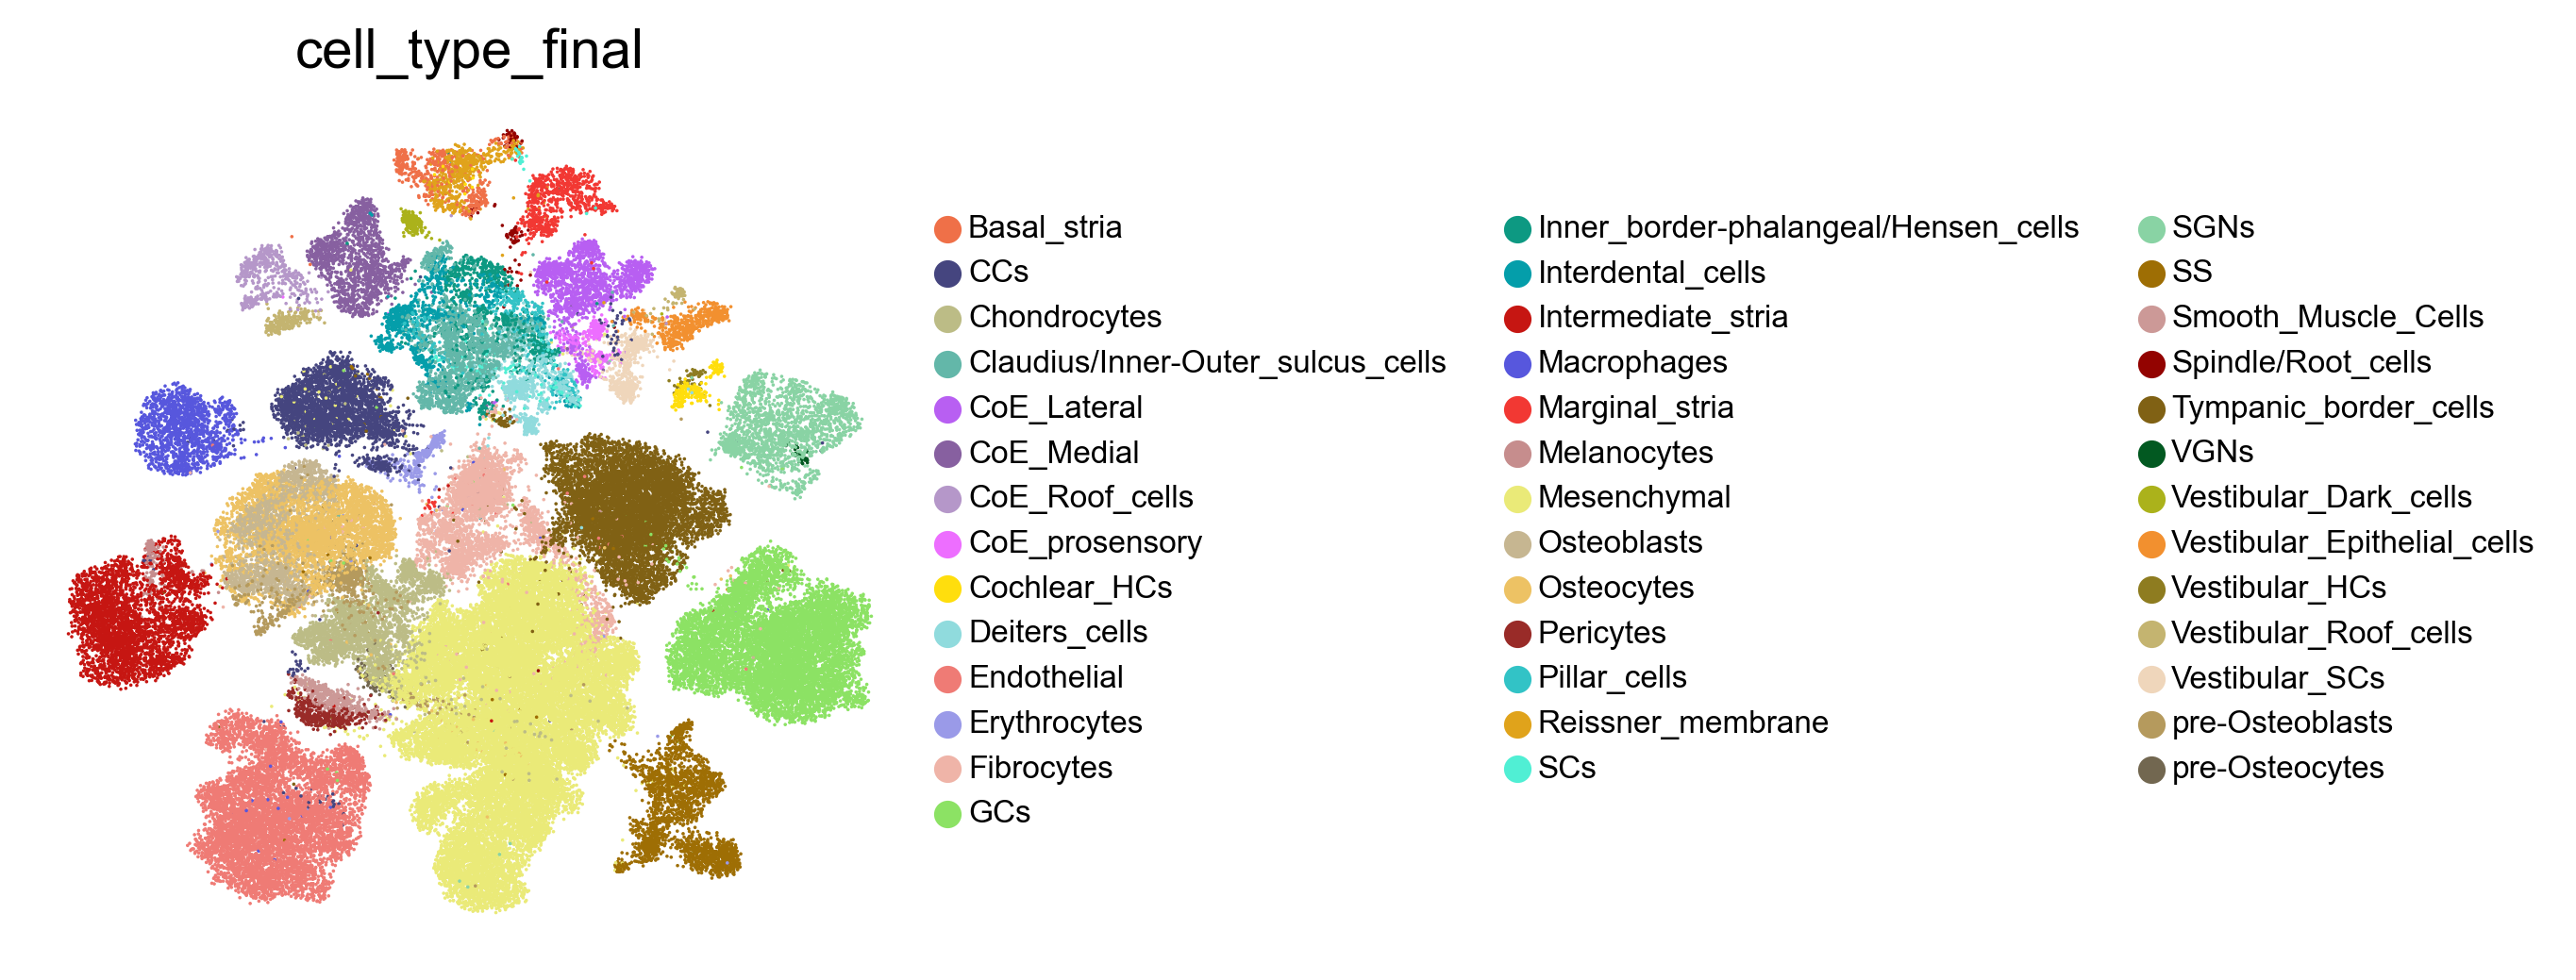

In [16]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.umap(
    adata,legend_fontsize=8,
    color="cell_type_final",
    palette={"Erythrocytes": "#9a9ae8", #Circulating cells
             "Macrophages": "#5757dd",
             "CCs": "#45457f",

              "Tympanic_border_cells": "#806114",# Surrounding structures
            "Reissner_membrane": "#e0a31b",
             "pre-Osteoblasts": "#b59a5d",
             "pre-Osteocytes": "#726750",
             "Osteoblasts": "#c6b691",
             "Osteocytes": "#edc264",
             "SS": "#9e6e04",

             "Endothelial": "#ef7b75",# Lateral wall
             "Pericytes": "#992b28",
             "Smooth_Muscle_Cells": "#cc9997",
             "Marginal_stria": "#f23833",
             "Intermediate_stria": "#c61612",
             "Basal_stria": "#ef7048",
             "Spindle/Root_cells": "#930300",
             "Fibrocytes": "#efb4a8",

             "Interdental_cells": "#049eaa",# Supporting cells
              "Pillar_cells": "#32c3c6",
              "Deiters_cells": "#90dbdd",
              "Inner_border-phalangeal/Hensen_cells": "#0d9982",
              "Claudius/Inner-Outer_sulcus_cells": "#63b7a9",
              "SCs": "#50efd4",

              "Cochlear_HCs": "#ffde0d",# Hair cells
               "Vestibular_HCs": "#8e7c20",
             
             "Vestibular_SCs": "#efd6bb", # Vestibular
               "Vestibular_Epithelial_cells": "#f2902f",
             "Vestibular_Roof_cells": "#c4b470",
               "Vestibular_Dark_cells": "#abb21b",

             "CoE_Lateral": "#b85ff2", # early cochlear domain
               "CoE_Medial": "#8760a0",
             "CoE_Roof_cells": "#b597c9",
               "CoE_prosensory": "#ed6eff",

             "SGNs": "#89d3a4",# Neurons
               "VGNs": "#025921",
             "GCs": "#8ce264",# Glial cells

              "Mesenchymal": "#eaea78",
             "Chondrocytes": "#bcbc86",
               "Melanocytes": "#c68d8d",
       
            
            },

    size=3,


    
)

In [18]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
#sc.pp.scale(adata)
adata.layers["logcounts"] = adata.X.copy()
adata.layers['logcounts']
adata

<82533x13994 sparse matrix of type '<class 'numpy.float64'>'
	with 158135233 stored elements in Compressed Sparse Row format>

AnnData object with n_obs × n_vars = 82533 × 13994
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'leiden_R', 'low_ncounts', 'high_mito', 'low_ncounts_high_mito', 'S_score', 'G2M_score', 'phase', 'scrublet_score', 'scrublet_cluster_score', 'zscore', 'bh_pval', 'bonf_pval', 'is_doublet', 'leiden_res1.0', 'is_doublet_scrub', 'leiden_res1.1', 'leiden_res4.0', 'leiden_res2.0', '_scvi_batch', '_scvi_labels', 'leiden_scanvi_2.0', 'leiden_scanvi_3.0', 'leiden_scanvi_4.0', 'cell_type_final'
    var: 'Gene', 'mt', 'gene_ids-0', 'feature_types-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'n_cells_by_co

In [25]:
cut_labels_4 = ['< 12', '< 16','< 20','< 24','< 28', ]
cut_bins = [0, 12, 16,20,24,28 ]

adata.obs["age_bins"] = pd.cut(adata.obs["gw"], bins=cut_bins, labels=cut_labels_4).astype("str")
adata.obs["age_bins"] = pd.Categorical(adata.obs["age_bins"], categories=cut_labels_4, ordered=True)
adata.obs["age_bins"]



9.5gw_AAACCCAAGCTGCCTG     < 12
9.5gw_AAACCCAAGGCTGTAG     < 12
9.5gw_AAACCCAGTTAGTCGT     < 12
9.5gw_AAACCCATCGGTCATA     < 12
9.5gw_AAACCCATCTACCCAC     < 12
                           ... 
26+3gw_TTTGTTGTCATGGATC    < 28
26+3gw_TTTGTTGTCCGATCGG    < 28
26+3gw_TTTGTTGTCGATGCAT    < 28
26+3gw_TTTGTTGTCGGCTATA    < 28
26+3gw_TTTGTTGTCTCATTTG    < 28
Name: age_bins, Length: 82533, dtype: category
Categories (5, object): ['< 12' < '< 16' < '< 20' < '< 24' < '< 28']

In [26]:
# Convert covariate to continous
adata.obs['age_bins'] = adata.obs['age_bins'].cat.codes
adata.obs['age_bins']
adata.obs.groupby(['gw','sample_id','age_bins']).apply(len)

9.5gw_AAACCCAAGCTGCCTG     0
9.5gw_AAACCCAAGGCTGTAG     0
9.5gw_AAACCCAGTTAGTCGT     0
9.5gw_AAACCCATCGGTCATA     0
9.5gw_AAACCCATCTACCCAC     0
                          ..
26+3gw_TTTGTTGTCATGGATC    4
26+3gw_TTTGTTGTCCGATCGG    4
26+3gw_TTTGTTGTCGATGCAT    4
26+3gw_TTTGTTGTCGGCTATA    4
26+3gw_TTTGTTGTCTCATTTG    4
Name: age_bins, Length: 82533, dtype: int8

gw  sample_id  age_bins
9   gw9        0            3463
11  gw11       0            3660
14  gw14       1           10504
15  gw15       1            1063
16  gw16       1            6684
17  gw17_1     2            5714
    gw17_2     2            5207
    gw17_3     2            2696
18  gw18       2            8207
20  gw20       2            3343
22  gw22_1     3            4646
    gw22_2     3            6924
23  gw23       3            2840
25  gw25       4           11354
26  gw26       4            6228
dtype: int64

In [27]:
# export loom file and related metadata and all of it uses to load in R for Milo analysis.
adata.write_loom(data_dir + 'human_cochlea_annotation.loom')
adata.obs.to_csv(data_dir +'human_cochlea_annotation_obs.csv')
adata.var.to_csv(data_dir +'human_cochlea_annotation_var.csv')

The loom file will lack these fields:
{'X_scANVI', '_scvi_extra_continuous_covs', 'X_pca', 'X_scVI', '_scvi_extra_categorical_covs', 'X_umap'}
Use write_obsm_varm=True to export multi-dimensional annotations


In [28]:
umap=pd.DataFrame(adata.obsm['X_umap']).to_csv(data_dir + 'human_cochlea_annotation_umap.csv')
umap

In [29]:
scANVI=pd.DataFrame(adata.obsm['X_scANVI']).to_csv(data_dir + 'human_cochlea_annotation_scANVI.csv')
umap